# Entrenamiento YOLO y evaluacion en videos

Este notebook deja el registro del baseline YOLO entrenado para clasificar acordes de guitarra a partir de imagenes. La idea es que el entrenamiento y sus resultados queden visibles en Jupyter, como bitacora del experimento.

Importante: este baseline clasifica el acorde visual del frame completo (`A`, `Am`, `C`, `G`, etc.). Todavia no resuelve cuerda por cuerda ni traste por traste; esa parte queda para la etapa de MediaPipe Hands + geometria del diapason.

## Objetivo del experimento

Entrenar un modelo YOLO de clasificacion usando el dataset `dduka/guitar-chords` de Hugging Face y luego aplicar ese modelo sobre frames extraidos de videos descargados. Con esto se valida que el modelo puede tomar frames de video y producir una etiqueta de acorde con una confianza asociada.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

PROJECT_ROOT

WindowsPath('C:/Users/dlinares/Documents/UVG/Vision/ProyectoFinal_VisionCompu')

## Verificacion de CUDA

El entrenamiento final se corrio con CUDA usando la GPU NVIDIA del equipo. La validacion esperada es que `torch.cuda.is_available()` devuelva `True`.

In [2]:
import torch

cuda_info = {
    "torch": torch.__version__,
    "cuda_compilada": torch.version.cuda,
    "cuda_disponible": torch.cuda.is_available(),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
}
cuda_info

{'torch': '2.10.0+cu128',
 'cuda_compilada': '12.8',
 'cuda_disponible': True,
 'gpu': 'NVIDIA GeForce RTX 4060 Laptop GPU'}

## Dataset usado

El dataset descargado desde Hugging Face trae imagenes etiquetadas con acordes. Como el split original no tenia todas las clases en validacion/test, se genero un split estratificado compatible con Ultralytics en `data/hf_guitar_chords_yolo`.

In [3]:
import pandas as pd

split_summary_path = PROJECT_ROOT / "data" / "hf_guitar_chords_yolo" / "split_summary.csv"
split_summary = pd.read_csv(split_summary_path)
summary_table = split_summary.pivot(index="label", columns="split", values="count").fillna(0).astype(int)
summary_table.loc["TOTAL"] = summary_table.sum(axis=0)
summary_table

split,test,train,val
label,,,
A,24,197,24
Am,13,104,13
B,24,197,24
Bm,13,104,13
C,24,196,24
Cm,41,324,41
D,14,117,14
Dm,13,104,13
E,14,116,14


## Comando de entrenamiento

Este fue el comando usado para entrenar el baseline de clasificacion. Se deja aqui como registro reproducible; no se ejecuta automaticamente en el notebook para evitar reentrenar el modelo cada vez que se abre.

In [4]:
train_command = r'''
$yolo = "$env:LOCALAPPDATA\Python\pythoncore-3.14-64\Scripts\yolo.exe"
& $yolo classify train model=yolo11n-cls.pt data=data/hf_guitar_chords_yolo epochs=20 imgsz=224 batch=32 workers=0 device=0 name=chord_cls_yolo exist_ok=True
'''
print(train_command.strip())

$yolo = "$env:LOCALAPPDATA\Python\pythoncore-3.14-64\Scripts\yolo.exe"
& $yolo classify train model=yolo11n-cls.pt data=data/hf_guitar_chords_yolo epochs=20 imgsz=224 batch=32 workers=0 device=0 name=chord_cls_yolo exist_ok=True


## Metricas de entrenamiento

Ultralytics guarda el historial del entrenamiento en `runs/classify/chord_cls_yolo/results.csv`. Aqui se carga la ultima fila para registrar el resultado final.

In [5]:
results_path = PROJECT_ROOT / "runs" / "classify" / "chord_cls_yolo" / "results.csv"
results = pd.read_csv(results_path)
results.columns = [col.strip() for col in results.columns]
last_row = results.tail(1).T
last_row.columns = ["valor_final"]
last_row

,valor_final
epoch,20.000000
time,1766.040000
train/loss,0.129300
metrics/accuracy_top1,0.951770
metrics/accuracy_top5,1.000000
val/loss,0.149020
lr/pg0,0.000033
lr/pg1,0.000033
lr/pg2,0.000033


In [6]:
metrics = {
    "epoch": int(results.iloc[-1]["epoch"]),
    "train_loss": float(results.iloc[-1]["train/loss"]),
    "val_loss": float(results.iloc[-1]["val/loss"]),
    "top1_val": float(results.iloc[-1]["metrics/accuracy_top1"]),
    "top5_val": float(results.iloc[-1]["metrics/accuracy_top5"]),
}
metrics

{'epoch': 20,
 'train_loss': 0.1293,
 'val_loss': 0.14902,
 'top1_val': 0.95177,
 'top5_val': 1.0}

## Evaluacion en test

La evaluacion separada sobre `test` se corrio con `yolo classify val ... split=test`. El resultado observado fue:

- `top1_acc = 0.923`
- `top5_acc = 0.994`

Eso significa que, en el split de prueba, la prediccion principal fue correcta en aproximadamente 92.3% de las imagenes; y el acorde correcto estuvo dentro de las 5 opciones mas probables en aproximadamente 99.4%.

## Videos usados para demo

Los videos descargados no tienen ground truth confirmado. Por eso se usan para ver transferencia visual y demo, no para reportar accuracy de acordes.

In [7]:
video_manifest = pd.read_csv(PROJECT_ROOT / "data" / "video_manifest.csv")
video_manifest

,file,size_bytes,duration_s,fps,frame_count,width,height,source,ground_truth,use_case,notes
0,data/139-135737102_medium.mp4,4050068,13.760,25.00,344,1280,720,internet,unknown,robustness_test,NaN
1,data/2662-161442863_medium.mp4,5415693,15.640,25.00,391,1280,720,internet,unknown,robustness_test,NaN
2,data/35867-408654189.mp4,16276204,26.560,29.97,796,1920,1080,internet,unknown,robustness_test,NaN
3,data/7240-199190963_medium.mp4,2570496,13.360,25.00,334,1280,720,internet,unknown,robustness_test,NaN
4,data/81950-576572872_medium.mp4,5080320,16.383,29.97,491,1280,720,internet,unknown,robustness_test,NaN
5,data/Video Con blurr.mp4,15263923,16.160,25.00,404,1920,1080,internet,unknown,robustness_test,NaN


## Predicciones sobre frames de video

Se extrajeron frames cada 2 segundos y se corrio el modelo entrenado sobre esos frames. El CSV resultante permite revisar que predijo el modelo, con su confianza.

In [8]:
frame_predictions = pd.read_csv(PROJECT_ROOT / "outputs" / "frame_predictions.csv")
frame_predictions.head(10)

,frame_path,source_frame_path,predicted_label,confidence
0,image0.jpg,data\video_frames\139-135737102_medium\frame_0...,B,0.311046
1,image1.jpg,data\video_frames\139-135737102_medium\frame_0...,G,0.637350
2,image2.jpg,data\video_frames\139-135737102_medium\frame_0...,G,0.539562
3,image3.jpg,data\video_frames\139-135737102_medium\frame_0...,G,0.287098
4,image4.jpg,data\video_frames\139-135737102_medium\frame_0...,G,0.332614
5,image5.jpg,data\video_frames\139-135737102_medium\frame_0...,G,0.481803
6,image6.jpg,data\video_frames\139-135737102_medium\frame_0...,G,0.581599
7,image7.jpg,data\video_frames\2662-161442863_medium\frame_...,B,0.477921
8,image8.jpg,data\video_frames\2662-161442863_medium\frame_...,D,0.657740
9,image9.jpg,data\video_frames\2662-161442863_medium\frame_...,A,0.676735


In [9]:
prediction_distribution = frame_predictions["predicted_label"].value_counts().rename_axis("acorde_predicho").reset_index(name="frames")
prediction_distribution

,acorde_predicho,frames
0,A,18
1,C,10
2,G,7
3,Gm,7
4,E,4
5,Cm,3
6,B,2
7,D,2
8,Dm,1


## Demo visual

El script `scripts/annotate_videos_yolo.py` genera videos con el acorde predicho dibujado arriba a la izquierda. Tambien tiene modo `--show` para ver el video mientras YOLO va prediciendo.

In [10]:
demo_command = r'''
python scripts\annotate_videos_yolo.py --model runs\classify\chord_cls_yolo\weights\best.pt --video-path data\139-135737102_medium.mp4 --out-dir outputs\annotated_videos --csv-dir outputs\video_predictions --predict-every 5 --show --display-scale 0.8
'''
print(demo_command.strip())

python scripts\annotate_videos_yolo.py --model runs\classify\chord_cls_yolo\weights\best.pt --video-path data\139-135737102_medium.mp4 --out-dir outputs\annotated_videos --csv-dir outputs\video_predictions --predict-every 5 --show --display-scale 0.8


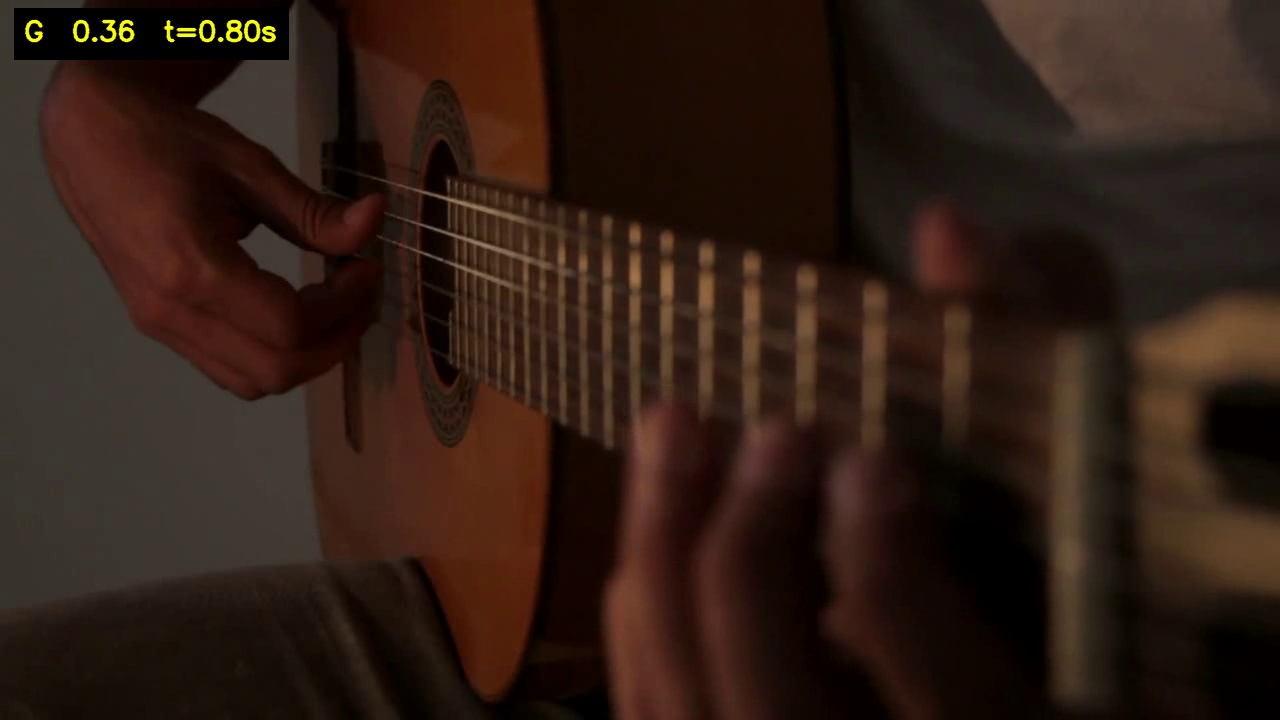

In [11]:
from IPython.display import Image, display

preview_path = PROJECT_ROOT / "outputs" / "annotated_videos" / "preview_139-135737102_medium.jpg"
if preview_path.exists():
    display(Image(filename=str(preview_path)))
else:
    print("No existe preview todavia. Ejecutar scripts/annotate_videos_yolo.py para generarlo.")

## Interpretacion de la etiqueta

Si en el video aparece algo como:

```text
G  0.69  t=7.60s
```

se interpreta asi:

- `G`: acorde predicho, en este caso Sol mayor.
- `0.69`: confianza del modelo, aproximadamente 69%.
- `t=7.60s`: segundo del video.

La notacion `A`, `B`, `C`, `D`, `E`, `F`, `G` es notacion musical estandar. La `m` indica acorde menor, por ejemplo `Em` = Mi menor y `Gm` = Sol menor.

## Siguiente etapa

Este baseline demuestra la clasificacion visual por frame. Para acercarnos mas a la idea original del proyecto, el siguiente paso es integrar MediaPipe Hands y estimar la relacion dedo-traste:

1. detectar mano y puntas de dedos;
2. detectar o calibrar el diapason;
3. mapear dedos a cuerda/traste;
4. comparar contra acordes predefinidos;
5. generar tablatura por intervalos estables.